In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Online Sales Data.csv')
df

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal
...,...,...,...,...,...,...,...,...,...
235,10236,2024-08-23,Home Appliances,Nespresso Vertuo Next Coffee and Espresso Maker,1,159.99,159.99,Europe,PayPal
236,10237,2024-08-24,Clothing,Nike Air Force 1 Sneakers,3,90.00,270.00,Asia,Debit Card
237,10238,2024-08-25,Books,The Handmaid's Tale by Margaret Atwood,3,10.99,32.97,North America,Credit Card
238,10239,2024-08-26,Beauty Products,Sunday Riley Luna Sleeping Night Oil,1,55.00,55.00,Europe,PayPal


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    240 non-null    int64  
 1   Date              240 non-null    object 
 2   Product Category  240 non-null    object 
 3   Product Name      240 non-null    object 
 4   Units Sold        240 non-null    int64  
 5   Unit Price        240 non-null    float64
 6   Total Revenue     240 non-null    float64
 7   Region            240 non-null    object 
 8   Payment Method    240 non-null    object 
dtypes: float64(2), int64(2), object(5)
memory usage: 17.0+ KB


In [4]:
# finding any null value

df.isnull().sum()

Transaction ID      0
Date                0
Product Category    0
Product Name        0
Units Sold          0
Unit Price          0
Total Revenue       0
Region              0
Payment Method      0
dtype: int64

In [5]:
# finding any duplicate values

df.duplicated().sum()

np.int64(0)

In [6]:
# conversion of float to int
df['Unit Price']= round(df['Unit Price'])
df['Total Revenue'] = round(df['Total Revenue'])

In [7]:
df

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,1000.0,2000.0,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,500.0,500.0,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,70.0,210.0,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,16.0,64.0,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,90.0,90.0,Europe,PayPal
...,...,...,...,...,...,...,...,...,...
235,10236,2024-08-23,Home Appliances,Nespresso Vertuo Next Coffee and Espresso Maker,1,160.0,160.0,Europe,PayPal
236,10237,2024-08-24,Clothing,Nike Air Force 1 Sneakers,3,90.0,270.0,Asia,Debit Card
237,10238,2024-08-25,Books,The Handmaid's Tale by Margaret Atwood,3,11.0,33.0,North America,Credit Card
238,10239,2024-08-26,Beauty Products,Sunday Riley Luna Sleeping Night Oil,1,55.0,55.0,Europe,PayPal


,month,mon_days
3,January,31
4,July,31
6,March,31
7,May,31
0,April,30
5,June,30
2,February,29
1,August,27


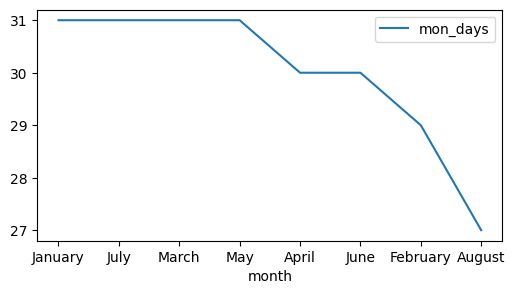

In [8]:
# finding the number of days' sales done each month

df['Date'] = pd.to_datetime(df['Date'])
df['month'] = df['Date'].dt.month_name()

mon_days = df.groupby('month').size().reset_index(name='mon_days').sort_values('mon_days',ascending=False)
mon_days.plot(x='month',figsize=(6,3))
mon_days

In [9]:
mon_days.min()

month       April
mon_days       27
dtype: object

In [10]:
mon_days.max()

month       May
mon_days     31
dtype: object

In [37]:
# finding products that max sold (top 10)

prod = df.groupby('Product Name')['Units Sold'].sum().reset_index().sort_values('Units Sold',ascending=False).head(10)
prod

,Product Name,Units Sold
93,Hanes ComfortSoft T-Shirt,10
181,The Catcher in the Rye by J.D. Salinger,7
225,Yeti Rambler Tumbler,6
74,Gap Essential Crewneck T-Shirt,6
173,Spalding NBA Street Basketball,6
132,Nike Air Force 1,6
70,Forever 21 Graphic Tee,5
212,Under Armour HeatGear T-Shirt,5
202,The Silent Patient by Alex Michaelides,5
38,Calvin Klein Boxer Briefs,5


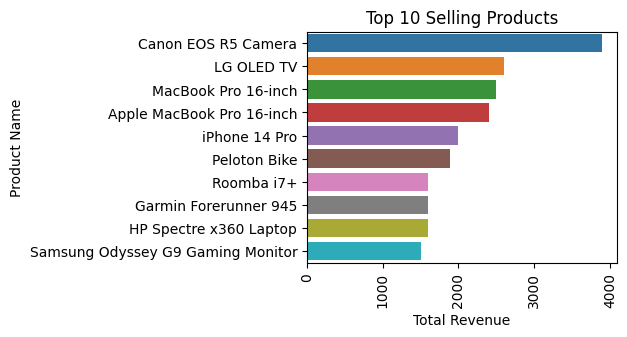

,Product Name,Total Revenue
39,Canon EOS R5 Camera,3900.0
111,LG OLED TV,2600.0
124,MacBook Pro 16-inch,2500.0
18,Apple MacBook Pro 16-inch,2399.0
230,iPhone 14 Pro,2000.0
151,Peloton Bike,1895.0
160,Roomba i7+,1600.0
79,Garmin Forerunner 945,1600.0
91,HP Spectre x360 Laptop,1600.0
165,Samsung Odyssey G9 Gaming Monitor,1500.0


In [42]:
## top 10 products that generate max revenue

max_rev = df.groupby('Product Name')['Total Revenue'].sum().reset_index().sort_values('Total Revenue',ascending=False).head(10)

plt.figure(figsize=(4,3))
sns.barplot(x='Total Revenue',y='Product Name',data=max_rev,hue='Product Name')
plt.title('Top 10 Selling Products')
plt.xticks(rotation=90)
plt.show()

max_rev

In [48]:
# number of sales per region

reg = df.groupby('Region').size().reset_index(name='sales')
reg

,Region,sales
0,Asia,80
1,Europe,80
2,North America,80


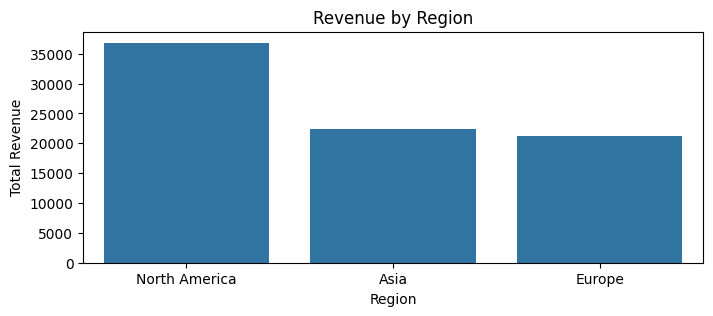

,Region,Total Revenue
2,North America,36846.0
0,Asia,22459.0
1,Europe,21270.0


In [63]:
# max revenue generated by which region

reg_rev = df.groupby('Region')['Total Revenue'].sum().reset_index().sort_values('Total Revenue',ascending=False)

plt.figure(figsize=(8,3))
sns.barplot(x='Region',y='Total Revenue',data=reg_rev)
plt.title('Revenue by Region')
plt.show()

reg_rev

In [89]:
# max using payment method

pay = df.groupby('Payment Method').size().reset_index(name='Preferred').sort_values('Preferred',ascending=False)
pay

,Payment Method,Preferred
0,Credit Card,120
2,PayPal,80
1,Debit Card,40


In [77]:
# Which region prefers which method mostly

mt = df.groupby(['Region','Payment Method'])['Payment Method'].count().reset_index(name='Preferred').sort_values('Preferred',ascending=False)
mt

,Region,Payment Method,Preferred
2,Europe,PayPal,80
3,North America,Credit Card,80
0,Asia,Credit Card,40
1,Asia,Debit Card,40


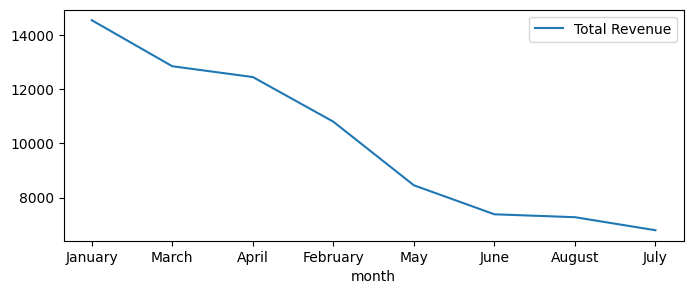

,month,Total Revenue
3,January,14549.0
6,March,12850.0
0,April,12452.0
2,February,10804.0
7,May,8457.0
5,June,7386.0
1,August,7279.0
4,July,6798.0


In [84]:
# Which month generates the highest revenue

mon_rev = df.groupby('month')['Total Revenue'].sum().reset_index().sort_values('Total Revenue',ascending=False)

mon_rev.plot(kind='line',x='month',figsize=(8,3))
plt.show()

mon_rev

In [91]:
# which region has the highest demand for which product category

reg_prod = df.groupby(['Region','Product Category']).size().reset_index(name='Sales')
reg_prod

,Region,Product Category,Sales
0,Asia,Clothing,40
1,Asia,Sports,40
2,Europe,Beauty Products,40
3,Europe,Home Appliances,40
4,North America,Books,40
5,North America,Electronics,40


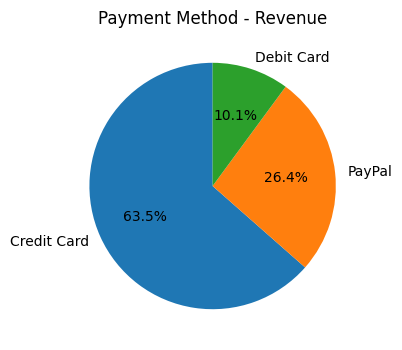

,Payment Method,Total Revenue
0,Credit Card,51174.0
2,PayPal,21270.0
1,Debit Card,8131.0


In [92]:
# which payment method generates the most revenue

pay_rev = df.groupby('Payment Method')['Total Revenue'].sum().reset_index().sort_values('Total Revenue',ascending=False)

plt.figure(figsize=(5,4))
plt.pie(
    pay_rev['Total Revenue'],          # values
    labels=pay_rev['Payment Method'],  # labels
    autopct='%1.1f%%',     # percentage
    startangle=90)
plt.title('Payment Method - Revenue')
plt.show()

pay_rev

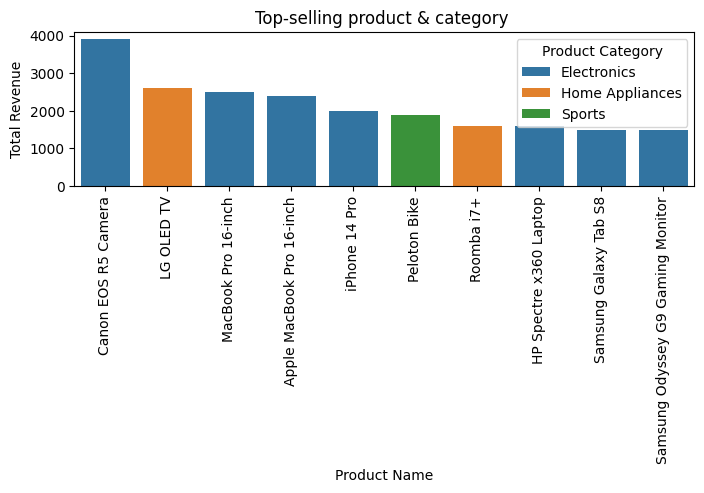

,Product Category,Product Name,amount
130,Electronics,Canon EOS R5 Camera,3900.0
182,Home Appliances,LG OLED TV,2600.0
142,Electronics,MacBook Pro 16-inch,2500.0
123,Electronics,Apple MacBook Pro 16-inch,2399.0
154,Electronics,iPhone 14 Pro,2000.0
217,Sports,Peloton Bike,1895.0
190,Home Appliances,Roomba i7+,1600.0
138,Electronics,HP Spectre x360 Laptop,1600.0
146,Electronics,Samsung Galaxy Tab S8,1500.0
149,Electronics,Samsung Odyssey G9 Gaming Monitor,1500.0


In [97]:
# top-selling product within each category

sale_prod = df.groupby(['Product Category','Product Name'])['Total Revenue'].sum().reset_index(name='amount').sort_values('amount',ascending=False).head(10)

plt.figure(figsize=(8,2))
sns.barplot(
    data=sale_prod,
    x='Product Name',
    y='amount',
    hue='Product Category')
plt.title('Top-selling product & category ')
plt.xticks(rotation=90)
plt.xlabel('Product Name')
plt.ylabel('Total Revenue')
plt.legend(title='Product Category')
plt.show()

sale_prod

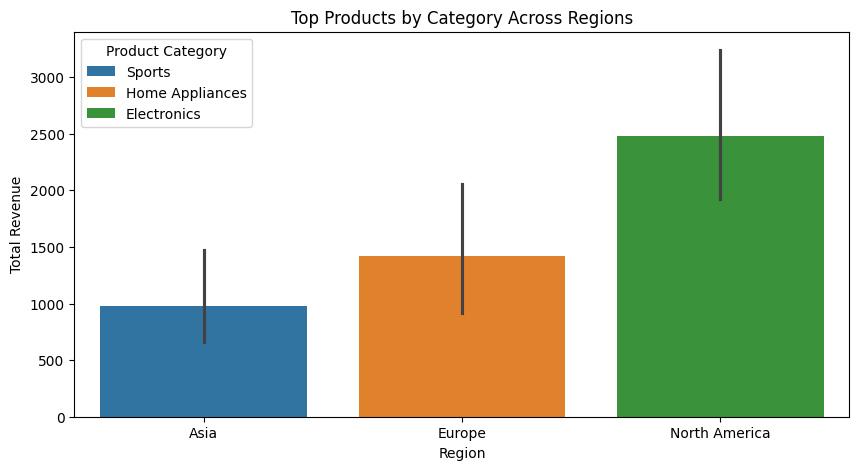

,Region,Product Category,Product Name,amount
63,Asia,Sports,Peloton Bike,1895.0
51,Asia,Sports,Garmin Fenix 6X Pro,1000.0
44,Asia,Sports,Bowflex SelectTech 1090 Adjustable Dumbbells,700.0
49,Asia,Sports,Fitbit Versa 3,690.0
41,Asia,Sports,Babolat Pure Drive Tennis Racket,600.0
147,Europe,Home Appliances,LG OLED TV,2600.0
155,Europe,Home Appliances,Roomba i7+,1600.0
122,Europe,Home Appliances,Blueair Classic 480i,1200.0
131,Europe,Home Appliances,De'Longhi Magnifica Espresso Machine,900.0
133,Europe,Home Appliances,Dyson Supersonic Hair Dryer,800.0


In [101]:
# which product within each category performs better in each region

reg_prod = df.groupby(['Region','Product Category','Product Name'])['Total Revenue'].sum().reset_index(name='amount').sort_values(['Region','amount'],ascending=[True,False]).groupby('Region').head(5)

plt.figure(figsize=(10,5))
sns.barplot(
    data=reg_prod,
    x='Region',
    y='amount',
    hue='Product Category'
)

plt.title('Top Products by Category Across Regions')
plt.ylabel('Total Revenue')
plt.show()

reg_prod